In [1]:
import torch
import pandas as pd
from torch_geometric.data import Data
from pathlib import Path
import os
os.chdir(Path().cwd().parent)
from modelling import get_dataframes
from modelling.metrics.metricstracker import MetricsTracker
import datetime


Running __init__.py for data pipeline...
Modelling package initialized

/opt/rocm/lib/libamd_smi.so: cannot open shared object file: No such file or directory
Unable to find amdsmi library try installing amd-smi-lib from your package manager


2025-03-17 19:26:10.465679: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-17 19:26:10.465777: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-17 19:26:10.465823: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-17 19:26:10.477545: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-17 19:26:11.836931: W tensorflow/compiler/

In [2]:
HABROK = bool(0)                  # set to True if using HABROK; it will print
                                  # all stdout to a .txt file to log progress
BASE_DIR = Path.cwd().parent
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_combined"
ALL_DIR = DATA_DIR / "all"

print("BASE_DIR: ", BASE_DIR)
print("MODEL_PATH: ", MODEL_PATH)

torch.manual_seed(34)             # set seed for reproducibility

N_HOURS_U = 72                    # number of hours to use for input
N_HOURS_Y = 24                    # number of hours to predict
N_HOURS_STEP = 24                 # "sampling rate" in hours of the data; e.g. 24 
                                  # means sample an I/O-pair every 24 hours
                                  # the contaminants and meteorological vars
CONTAMINANTS = ['NO2', 'O3'] # 'PM10', 'PM25']

BASE_DIR:  /home/nick/bachelor-project/forecasting_smog_DL_GNN
MODEL_PATH:  /home/nick/bachelor-project/forecasting_smog_DL_GNN/results/models


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tracker = MetricsTracker(
    experiment_name='GNN',
    log_dir=BASE_DIR / "src" / 'results' / 'energy_logs',
    track_energy=True,
    track_tensorboard=True,
    track_memory=True,
    verbose=True,
)

cuda
[2025-03-17 19:26:12,419] [zeus.device.gpu.nvidia](nvidia.py:47) pynvml is available and initialized.
[2025-03-17 19:26:12,432] [zeus.device.cpu.rapl](rapl.py:137) RAPL is not supported on this CPU.
[2025-03-17 19:26:12,433] [zeus.monitor.energy](energy.py:209) Monitoring GPU indices [0].
[2025-03-17 19:26:12,434] [zeus.monitor.energy](energy.py:210) Monitoring CPU indices []
[2025-03-17 19:26:12,435] [zeus.monitor.energy](energy.py:219) Writing measurement logs to /home/nick/bachelor-project/forecasting_smog_DL_GNN/src/results/energy_logs/GNN_20250317_192612/energy_20250317_192612.csv.


In [4]:
import torch

def load_data(cities, is_train=True):
    """
    Load training or validation data for each city.

    Args:
        cities (list): List of cities (folder names).
        is_train (bool): Flag to specify whether loading train data (True) or val data (False).
    
    Returns:
        torch.Tensor: Node feature tensor (x).
        torch.Tensor: Node label tensor (y).
    """
    # Initialize lists for features and labels
    node_features = []
    node_labels = []

    for city in cities:
        city_path = ALL_DIR / city
        
        # Select the appropriate file pattern (train or validation)
        data_type = "train" if is_train else "val"
        feature_pattern = f"{data_type}_u.csv"
        label_pattern = f"{data_type}_y.csv"
        
        # Get all feature and label files for the city
        feature_files = sorted([f for f in os.listdir(city_path) if f.startswith(data_type) and f.endswith("_u.csv")])
        label_files = sorted([f for f in os.listdir(city_path) if f.startswith(data_type) and f.endswith("_y.csv")])

        # Read and aggregate features across all years (or months, days, etc.)
        city_features = []
        city_labels = []
        
        for feat_file, label_file in zip(feature_files, label_files):
            feat_df = pd.read_csv(os.path.join(city_path, feat_file), delimiter=";").drop(columns=["DateTime"])
            label_df = pd.read_csv(os.path.join(city_path, label_file), delimiter=";").drop(columns=["DateTime"])
            
            city_features.append(feat_df.mean(axis=0))  # Aggregate features (e.g., over time)
            city_labels.append(label_df.mean(axis=0))  # Aggregate labels (e.g., over time)

        # Compute overall mean feature vector for the city
        node_features.append(pd.concat(city_features, axis=1).mean(axis=1).values)
        node_labels.append(pd.concat(city_labels, axis=1).mean(axis=1).values)

    # Convert lists to PyTorch tensors
    x = torch.tensor(node_features, dtype=torch.float)
    y = torch.tensor(node_labels, dtype=torch.float)

    print(f"Node feature shape ({'train' if is_train else 'val'}):", x.shape)
    print(f"Node label shape ({'train' if is_train else 'val'}):", y.shape)

    return x, y

cities = ["amsterdam", "rotterdam", "utrecht"]

# Load training data
train_features, train_labels = load_data(cities, is_train=True)

# Load validation data
val_features, val_labels = load_data(cities, is_train=False)


Node feature shape (train): torch.Size([3, 8])
Node label shape (train): torch.Size([3, 2])
Node feature shape (val): torch.Size([3, 8])
Node label shape (val): torch.Size([3, 2])


/tmp/ipykernel_3056/415858764.py:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  x = torch.tensor(node_features, dtype=torch.float)


In [5]:

edges = [
    (0, 1), (1, 0),  # edge between city0 and city1 (bidirectional)
    (0, 2), (2, 0),  # edge between city0 and city2 (bidirectional)
    (1, 2), (2, 1)   # edge between city1 and city2 (bidirectional)
]

# Convert the edges into an edge_index tensor in PyG format
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print("Edge index:\n", edge_index)



Edge index:
 tensor([[0, 1, 0, 2, 1, 2],
        [1, 0, 2, 0, 2, 1]])


In [6]:
from torch_geometric.loader import DataLoader

train_data = Data(x=train_features, edge_index=edge_index, y=train_labels)
val_data = Data(x=val_features, edge_index=edge_index, y=val_labels)

In [7]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GNN(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(input_dim, 16)
        self.conv2 = GCNConv(16, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GNN(input_dim=train_features.shape[1], output_dim=train_labels.shape[1])
model.to(device)


GNN(
  (conv1): GCNConv(8, 16)
  (conv2): GCNConv(16, 2)
)

In [8]:
import torch.optim as optim
from torch_geometric.data import DataLoader

# Define your optimizer and criterion
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.MSELoss()

# Training loop
@tracker.track_window("epoch")
def train_epoch(epoch: int, train_data, model, criterion, optimizer, val_data):
    model.train()
    optimizer.zero_grad()

    # Training step for the single graph (one batch)
    optimizer.zero_grad()
    output = model(train_data)  # Correct usage of train_data.x and train_data.edge_index
    loss = criterion(output, train_data.y)
    loss.backward()
    optimizer.step()

    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        val_output = model(val_data)  # Validate the model using the validation data
        val_loss += criterion(val_output, val_data.y).item()

    # Calculate average validation loss
    val_loss /= 1  # Since you're passing just one graph (i.e., no batching)

    return {"epoch": epoch, "train_loss": loss.item(), "val_loss": val_loss}

# Run training for 100 epochs (or desired number of epochs)
for epoch in range(50):
    result, _ = train_epoch(epoch, train_data.to(device), model, criterion, optimizer, val_data.to(device))
    print(f"Epoch {epoch}, Train Loss: {result['train_loss']}, Val Loss: {result['val_loss']}")


[2025-03-17 19:26:14,143] [zeus.utils.framework](framework.py:25) PyTorch with CUDA support is available.
Starting tracking for epoch

Epoch 0:
  Train Loss: 0.0602
  Val Loss: 0.0219
  Epoch Energy: 24.32J
  Epoch Time: 1.03s
Epoch 0, Train Loss: 0.06015166640281677, Val Loss: 0.02192503772675991
Starting tracking for epoch

Epoch 1:
  Train Loss: 0.0260
  Val Loss: 0.0053
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 1, Train Loss: 0.026026520878076553, Val Loss: 0.0052534304559230804
Starting tracking for epoch

Epoch 2:
  Train Loss: 0.0064
  Val Loss: 0.0003
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 2, Train Loss: 0.006423749029636383, Val Loss: 0.00029930006712675095
Starting tracking for epoch

Epoch 3:
  Train Loss: 0.0002
  Val Loss: 0.0037
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 3, Train Loss: 0.00017777419998310506, Val Loss: 0.0037009031511843204
Starting tracking for epoch

Epoch 4:
  Train Loss: 0.0036
  Val Loss: 0.0097
  Epoch Energy: 0.00J
  Epoch Time:

/home/nick/bachelor-project/forecasting_smog_DL_GNN/.venv/lib/python3.10/site-packages/zeus/monitor/energy.py:403: UserWarning: The energy consumption of one or more GPUs was measured as zero. This means that the time duration of the measurement window was shorter than the GPU's energy counter update period. Consider turning on the `approx_instant_energy` option in `ZeusMonitor`, which approximates the energy consumption of a short time window as instant power draw x window duration.
  warnings.warn(


Starting tracking for epoch

Epoch 19:
  Train Loss: 0.0027
  Val Loss: 0.0013
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 19, Train Loss: 0.0026805931702256203, Val Loss: 0.0012561893090605736
Starting tracking for epoch

Epoch 20:
  Train Loss: 0.0014
  Val Loss: 0.0005
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 20, Train Loss: 0.0013967175036668777, Val Loss: 0.0005026856088079512
Starting tracking for epoch

Epoch 21:
  Train Loss: 0.0005
  Val Loss: 0.0002
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 21, Train Loss: 0.00048666991642676294, Val Loss: 0.00023935106582939625
Starting tracking for epoch

Epoch 22:
  Train Loss: 0.0001
  Val Loss: 0.0004
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 22, Train Loss: 0.00013619181117974222, Val Loss: 0.00044070923468098044
Starting tracking for epoch

Epoch 23:
  Train Loss: 0.0003
  Val Loss: 0.0009
  Epoch Energy: 1.00J
  Epoch Time: 0.01s
Epoch 23, Train Loss: 0.00032048788852989674, Val Loss: 0.0009278384386561811
Start

Plotting memory metrics



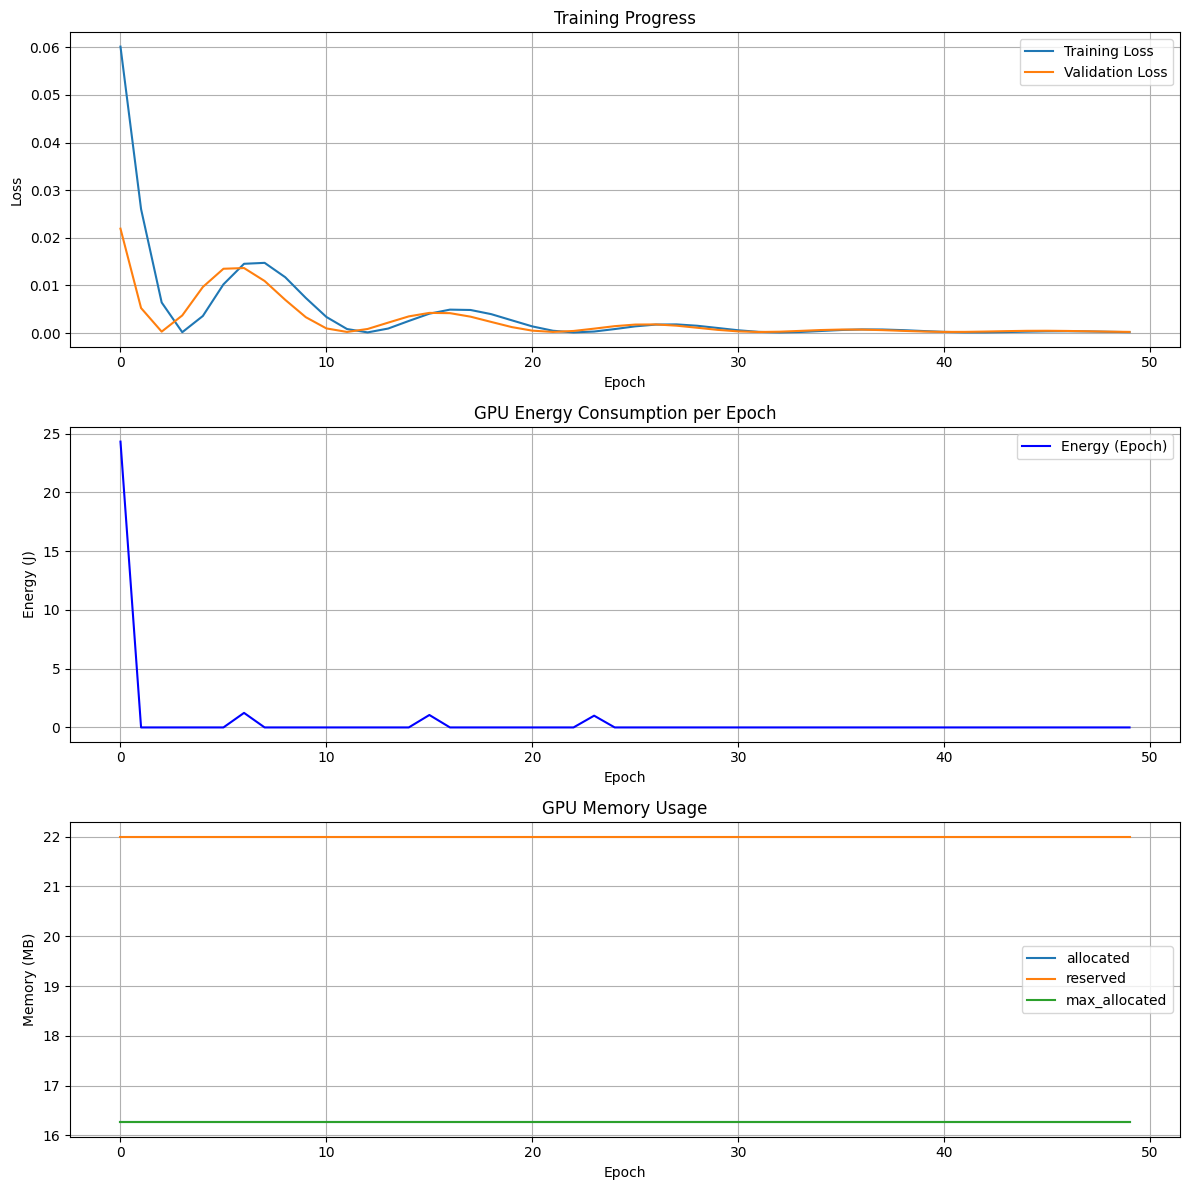

In [9]:
tracker.plot_metrics()

In [10]:
test_features = []
y_true = []

for city in cities:
    city_path = ALL_DIR / city

    # Get test feature and label files for the latest test year (e.g., 2023)
    test_feature_files = sorted([f for f in os.listdir(city_path) if f.startswith("test_") and f.endswith("_u.csv")])
    test_label_files = sorted([f for f in os.listdir(city_path) if f.startswith("test_") and f.endswith("_y.csv")])

    city_test_features = []
    city_test_labels = []

    for feat_file, label_file in zip(test_feature_files, test_label_files):
        feat_df = pd.read_csv(os.path.join(city_path, feat_file), delimiter=";").drop(columns=["DateTime"])
        label_df = pd.read_csv(os.path.join(city_path, label_file), delimiter=";").drop(columns=["DateTime"])

        city_test_features.append(feat_df.mean(axis=0))  # Aggregate over time
        city_test_labels.append(label_df.mean(axis=0))  # Aggregate over time

    # Compute mean feature vector and label per city
    test_features.append(pd.concat(city_test_features, axis=1).mean(axis=1).values)
    y_true.append(pd.concat(city_test_labels, axis=1).mean(axis=1).values)

# Convert to PyTorch tensors
x_test = torch.tensor(test_features, dtype=torch.float)
y_true = torch.tensor(y_true, dtype=torch.float)
y_true.to(device)

tensor([[0.1464, 0.1528],
        [0.1878, 0.1411],
        [0.1873, 0.1696]], device='cuda:0')

In [11]:
test_data = Data(x=x_test, edge_index=edge_index)  # Use same edges
test_data.to(device)

model.eval()
with torch.no_grad():
    y_pred = model(test_data)
y_pred.to(device)

tensor([[0.1593, 0.2178],
        [0.1593, 0.2178],
        [0.1593, 0.2178]], device='cuda:0')

In [12]:
# rescale the predictions based on 'O3': {'min': -5.0, 'max': 205.0},
#  'NO2': {'min': -2.6, 'max': 177.6},

O3_min, O3_max = -5.0, 205.0
NO2_min, NO2_max = -2.6, 177.6

y_pred[:, 0] = y_pred[:, 0] * (O3_max - O3_min) + O3_min
y_pred[:, 1] = y_pred[:, 1] * (NO2_max - NO2_min) + NO2_min

y_true[:, 0] = y_true[:, 0] * (O3_max - O3_min) + O3_min
y_true[:, 1] = y_true[:, 1] * (NO2_max - NO2_min) + NO2_min

In [13]:
import torch.nn.functional as F

y_pred = y_pred.to(device)
y_true = y_true.to(device)

mse = F.mse_loss(y_pred, y_true)
rmse = torch.sqrt(mse)
print(f"Test RMSE: {rmse.item()}")


Test RMSE: 8.9616117477417


In [14]:
# MSE for NO2
mse_NO2 = F.mse_loss(y_pred[:, 1], y_true[:, 1])

# RMSE for NO2
rmse_NO2 = torch.sqrt(mse_NO2)

print(f"Test RMSE for NO2: {rmse_NO2.item()}")

# MSE for O3
mse_O3 = F.mse_loss(y_pred[:, 0], y_true[:, 0])

# RMSE for O3
rmse_O3 = torch.sqrt(mse_O3)

print(f"Test RMSE for O3: {rmse_O3.item()}")

Test RMSE for NO2: 11.609374046325684
Test RMSE for O3: 5.083641052246094


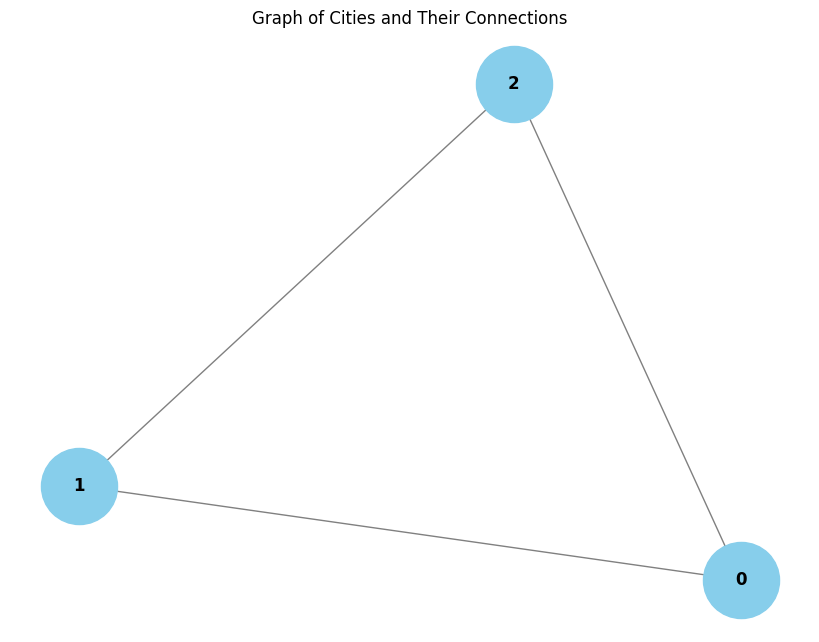

In [15]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_graph(data):
    """
    Visualizes the graph using NetworkX and Matplotlib.
    """
    # Create a NetworkX graph from edge_index (PyG format)
    G = nx.Graph()
    
    # Add nodes (cities)
    num_nodes = data.x.shape[0]
    cities = ["Amsterdam", "Rotterdam", "Utrecht"]  # Names of the cities
    
    # Add nodes to the graph with labels (cities)
    G.add_nodes_from(range(num_nodes))
    
    # Add edges to the graph
    edge_list = data.edge_index.t().tolist()
    G.add_edges_from(edge_list)

    # Draw the graph
    pos = nx.spring_layout(G)  # Use spring layout for positioning the nodes
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=12, font_weight='bold', edge_color='gray')
    plt.title("Graph of Cities and Their Connections")
    plt.show()

# Call the function to visualize the graph
visualize_graph(val_data)  # You can replace with 'val_data' or 'test_data' to visualize other graphs
